로지스틱 회귀 실습

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

#데이터 정의 (x = 운동시간, y = 감량여부)
data = [[3, 0], [6, 0], [9, 0], [12, 1], [15, 1], [18, 1], [21 ,1]]
# (x, _) => 첫 번째 값만 뽑기
x_data = np.array([x for x, _ in data], dtype=np.float64)
y_data = np.array([y for _, y in data], dtype=np.float64)

#변수 a, b 초기값 설정
a = tf.Variable(tf.random.normal([1], dtype=tf.float64, seed = 0))
b = tf.Variable(tf.random.normal([1], dtype=tf.float64, seed = 0))

#시그모이드 정의
def hypothesis(a, b):
    return 1 / (1+ tf.math.exp(-(a * x_data + b)))

#손실 함수 정의 (1e-7은 log(0) 에러를 방지하기 위해 붙이는 작은 수)
def cost(a, b):
    return -tf.reduce_mean(
        y_data * tf.math.log(hypothesis(a, b)+ 1e-7) +
        (1-y_data) * tf.math.log(1-hypothesis(a, b) + 1e-7)
    )

optimizer = tf.keras.optimizers.SGD(learning_rate = 0.5)

for i in range(50001):
    with tf.GradientTape() as tape:
        current_cost = cost(a, b)
    grads = tape.gradient(current_cost, [a, b])
    optimizer.apply_gradients(zip(grads, [a, b]))

    if i % 5000 == 0:
        print(f"Step: {i}, Cost: {current_cost.numpy():.6f}, a: {a.numpy()}, b: {b.numpy()}")

print(f"\n최종 결과 - a: {a.numpy()}, b: {b.numpy()}")

Step: 0, Cost: 6.157738, a: [3.91760189], b: [-0.03064279]
Step: 5000, Cost: 0.014697, a: [1.9702064], b: [-20.53634094]
Step: 10000, Cost: 0.008549, a: [2.33712577], b: [-24.39272231]
Step: 15000, Cost: 0.006010, a: [2.57464298], b: [-26.88808116]
Step: 20000, Cost: 0.004628, a: [2.75029913], b: [-28.73322208]
Step: 25000, Cost: 0.003760, a: [2.88963268], b: [-30.19668688]
Step: 30000, Cost: 0.003165, a: [3.00506917], b: [-31.40908315]
Step: 35000, Cost: 0.002732, a: [3.10359119], b: [-32.44379022]
Step: 40000, Cost: 0.002403, a: [3.18951274], b: [-33.34613705]
Step: 45000, Cost: 0.002145, a: [3.26568526], b: [-34.14608179]
Step: 50000, Cost: 0.001936, a: [3.33409144], b: [-34.86445381]

최종 결과 - a: [3.33409144], b: [-34.86445381]


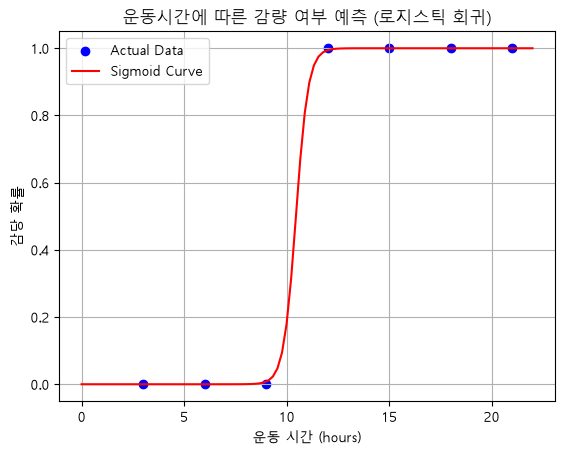

In [8]:
import platform
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib import font_manager,rc
import platform
# 한글 폰트 설정
if platform.system() == 'Windows':# 윈도우인 경우
    font_path = "c:/Windows/Fonts/malgun.ttf" # 맑은 고딕 폰트 경로
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    plt.rc('font', family=font_name)
elif platform.system() == 'Darwin': # macOS인 경우
    plt.rc('font', family='AppleGothic')
else: # Linux 등 다른 OS인 경우
    plt.rc('font', family='NanumGothic')
# 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

plt.scatter(x_data, y_data, color = 'blue', label = 'Actual Data')
x_range = np.linspace(0, 22, 100)
y_pred = 1/ (1+np.exp(-(a.numpy() * x_range + b.numpy())))
plt.plot(x_range, y_pred, color = 'red', label= "Sigmoid Curve")

plt.title('운동시간에 따른 감량 여부 예측 (로지스틱 회귀)')
plt.xlabel('운동 시간 (hours)')
plt.ylabel('감당 확률')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#x의 값을 두 가지로 설정 하였을 때

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

x_data = np.array([[3, 2.5], [6, 2.35], [9, 2.35], [12, 2.35], [15, 2.2], [18, 2.25], [21, 2.1]], dtype = np.float32)
y_data = np.array([0,0,0,1,1,1,1], dtype=np.float32).reshape(7, 1)

#변수 a, b 초기값 설정
a = tf.Variable(tf.random.normal([2, 1], dtype=tf.float32))
b = tf.Variable(tf.random.normal([1], dtype=tf.float32))

#시그모이드 정의
def hypothesis(a, b):
    return tf.sigmoid(tf.matmul(x_data, a) + b)

#손실 함수 정의 (1e-7은 log(0) 에러를 방지하기 위해 붙이는 작은 수)
def cost(a, b):
    return -tf.reduce_mean(
        y_data * tf.math.log(hypothesis(a, b)+ 1e-7) +
        (1-y_data) * tf.math.log(1-hypothesis(a, b) + 1e-7)
    )

optimizer = tf.keras.optimizers.SGD(learning_rate = 0.1)
epoch_arr = []
cost_arr = []
accuracy_arr = []

for i in range(2001):
    with tf.GradientTape() as tape:
        current_cost = cost(a, b)
    grads = tape.gradient(current_cost, [a, b])
    optimizer.apply_gradients(zip(grads, [a, b]))

    if i % 200 == 0:
        print(f"Step: {i}, Cost: {current_cost.numpy()}, a1: {a.numpy()[0,0]}, a2: {a.numpy()[1,0]} b: {b.numpy()}")

    predicted = tf.cast(hypothesis(a, b) > 0.5, dtype=tf.float32)
    epoch_arr.append(i)
    cost_arr.append(current_cost.numpy())
    accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted, y_data), dtype=tf.float64))
    accuracy_arr.append(accuracy)

print("===========================================")
print("a =", a.numpy())
print("b =", b.numpy()[0])

def graph():
    fig, ax1 = plt.subplots()

    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Cost', color='tab:red')
    ax1.plot(epoch_arr, cost_arr, color='tab:red', label='Cost')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx()  # x축 공유
    ax2.set_ylabel('Accuracy', color='tab:blue')
    ax2.plot(epoch_arr, accuracy_arr, color='tab:blue', label='Accuracy')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    fig.tight_layout()
    plt.title('Cost & Accuracy over Epochs')
    plt.show()
print("y_data =", y_data)
print("sigmoid =", hypothesis(a, b).numpy())
print("predicted =", predicted.numpy())
print("Accuracy =", accuracy.numpy())

Step: 0, Cost: 4.695809841156006, a1: 1.3006713390350342, a2: 0.3323812782764435 b: [1.0292629]
Step: 200, Cost: 0.12140161544084549, a1: 0.5869547128677368, a2: -2.475473642349243 b: [-0.11681647]
Step: 400, Cost: 0.08613085001707077, a1: 0.7792559266090393, a2: -3.2204482555389404 b: [-0.42798263]
Step: 600, Cost: 0.06944835931062698, a1: 0.9139068126678467, a2: -3.7359049320220947 b: [-0.64495486]
Step: 800, Cost: 0.0589258074760437, a1: 1.021425485610962, a2: -4.145732879638672 b: [-0.818115]
Step: 1000, Cost: 0.05144177004694939, a1: 1.112320065498352, a2: -4.491475582122803 b: [-0.96450907]
Step: 1200, Cost: 0.04575565829873085, a1: 1.1916520595550537, a2: -4.792880058288574 b: [-1.092298]
Step: 1400, Cost: 0.04125051572918892, a1: 1.2623240947723389, a2: -5.061180114746094 b: [-1.2061528]
Step: 1600, Cost: 0.03757501393556595, a1: 1.3261929750442505, a2: -5.303527355194092 b: [-1.3090575]
Step: 1800, Cost: 0.03451024368405342, a1: 1.3845388889312744, a2: -5.524836540222168 b: [-

In [16]:
def graph():
    fig, ax1 = plt.subplots()

    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Cost', color='tab:red')
    ax1.plot(epoch_arr, cost_arr, color='tab:red', label='Cost')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx()  # x축 공유
    ax2.set_ylabel('Accuracy', color='tab:blue')
    ax2.plot(epoch_arr, accuracy_arr, color='tab:blue', label='Accuracy')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    fig.tight_layout()
    plt.title('Cost & Accuracy over Epochs')
    plt.show()

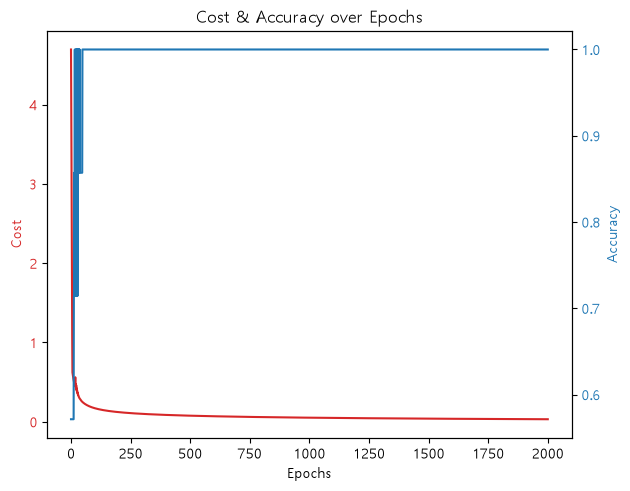

In [17]:
graph()

In [18]:
new_x = np.array([[3, 2.5], [6, 2.35], [9, 2.35], [12, 2.35], [15, 2.2], [18, 2.25], [21, 2.1]], dtype = np.float32)

def predict(x):
    return tf.sigmoid(tf.matmul(x, a)+ b)

pred_prob = predict(new_x).numpy()

pred_class = (pred_prob > 0.5).astype(int)

for i in range(len(new_x)):
    print(f"입력 {new_x[i]} -> 확률= {pred_prob[i, 0]:.4f}, 예측 클래스 = {pred_class[i, 0]}")

입력 [3.  2.5] -> 확률= 0.0000, 예측 클래스 = 0
입력 [6.   2.35] -> 확률= 0.0018, 예측 클래스 = 0
입력 [9.   2.35] -> 확률= 0.1184, 예측 클래스 = 0
입력 [12.    2.35] -> 확률= 0.9095, 예측 클래스 = 1
입력 [15.   2.2] -> 확률= 0.9994, 예측 클래스 = 1
입력 [18.    2.25] -> 확률= 1.0000, 예측 클래스 = 1
입력 [21.   2.1] -> 확률= 1.0000, 예측 클래스 = 1


In [20]:
Y = tf.constant([0,0,0,0,0,0,1,1,1,1], dtype=tf.float64)
y_data = [0.1, 0.2, 0.3, 0.1, 0.2, 0.6, 0.7, 0.8, 0.6, 0.9]
y = tf.constant(y_data, dtype=tf.float64)

predicted = tf.cast(y > 0.5, dtype=tf.float64)

accuracy_tensor = tf.reduce_mean(tf.cast(tf.equal(predicted, Y), dtype=tf.float64))

print("예측 결과 (True/False):", tf.equal(predicted, Y).numpy())
print("예측 결과 (0/1):", tf.cast(tf.equal(predicted, Y),dtype=tf.float64).numpy())
print("정확도: ", accuracy_tensor.numpy())


예측 결과 (True/False): [ True  True  True  True  True False  True  True  True  True]
예측 결과 (0/1): [1. 1. 1. 1. 1. 0. 1. 1. 1. 1.]
정확도:  0.9


다중 로지스틱 회귀 실습
- "data-03-diabetes.csv" 파일 사용
- x_data, y_data 3개 출력

In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

#당뇨병 데이터 불러오기
data = np.loadtxt('Data/data-03-diabetes.csv', delimiter = ',', dtype=np.float32)
x_data = data[:, 0:-1]
y_data = data[:, [-1]]

seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

w = tf.Variable(tf.random.normal([8, 1], dtype=tf.float32))
b = tf.Variable(tf.random.normal([1], dtype=tf.float32))

def hypothesis(w, b):
    return tf.sigmoid(tf.matmul(x_data, w) + b)

def cost(w, b):
    return -tf.reduce_mean(y_data * tf.math.log(hypothesis(w, b)) + 1e-7 + (1 - y_data) * tf.math.log(1-hypothesis(w, b)) + 1e-7)

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

epoch_arr = []
cost_arr = []
accuracy_arr = []

for i in range(2001):
    with tf.GradientTape() as tape:
        current_cost = cost(w, b)
    grads = tape.gradient(current_cost, [w, b])
    optimizer.apply_gradients(zip(grads, [w, b]))


    if i % 200 == 0:
        print(f"Step: {i}, Cost: {current_cost.numpy():.6f}, a: {a.numpy()}, b: {b.numpy()}")

print(f"\n최종 결과 - a : {a.numpy()}, b: { b.numpy()}")




Step: 0, Cost: 0.798895, a: [[ 1.4382854]
 [-5.7286415]], b: [1.067293]
Step: 200, Cost: 0.757199, a: [[ 1.4382854]
 [-5.7286415]], b: [1.0998144]
Step: 400, Cost: 0.728476, a: [[ 1.4382854]
 [-5.7286415]], b: [1.0784074]
Step: 600, Cost: 0.703963, a: [[ 1.4382854]
 [-5.7286415]], b: [1.0380676]
Step: 800, Cost: 0.682118, a: [[ 1.4382854]
 [-5.7286415]], b: [0.9924978]
Step: 1000, Cost: 0.662533, a: [[ 1.4382854]
 [-5.7286415]], b: [0.94711405]
Step: 1200, Cost: 0.644982, a: [[ 1.4382854]
 [-5.7286415]], b: [0.9039799]
Step: 1400, Cost: 0.629273, a: [[ 1.4382854]
 [-5.7286415]], b: [0.8637816]
Step: 1600, Cost: 0.615224, a: [[ 1.4382854]
 [-5.7286415]], b: [0.82664126]
Step: 1800, Cost: 0.602664, a: [[ 1.4382854]
 [-5.7286415]], b: [0.792457]
Step: 2000, Cost: 0.591437, a: [[ 1.4382854]
 [-5.7286415]], b: [0.7610422]

최종 결과 - a : [[ 1.4382854]
 [-5.7286415]], b: [0.7610422]


In [31]:
hypo = hypothesis(w, b)

# (2) 0.5 기준으로 예측 클래스(0.0 또는 1.0) 판정
predicted = tf.cast(hypo > 0.5, dtype=tf.float32)

# (3) 예측치와 실제 정답(y_data) 비교하여 일치율 계산
is_correct = tf.equal(predicted, y_data)                  # True/False 텐서
accuracy = tf.reduce_mean(tf.cast(is_correct, dtype=tf.float32))  # 평균(정확도)

# 8. 결과 출력
print("==========================================")
print("예측 확률 (상위 5개)  :\n", hypo.numpy()[:5])
print("\n예측 결과 (상위 5개)  :\n", predicted.numpy()[:5])
print("\n실제 정답 (상위 5개)  :\n", y_data[:5])
print("==========================================")
print(f"최종 정확도 (Accuracy): {accuracy.numpy():.4f} ({accuracy.numpy()*100:.2f}%)")

예측 확률 (상위 5개)  :
 [[0.61902934]
 [0.6699929 ]
 [0.4378792 ]
 [0.8802296 ]
 [0.7343562 ]]

예측 결과 (상위 5개)  :
 [[1.]
 [1.]
 [0.]
 [1.]
 [1.]]

실제 정답 (상위 5개)  :
 [[0.]
 [1.]
 [0.]
 [1.]
 [0.]]
최종 정확도 (Accuracy): 0.6812 (68.12%)


epochs=0, cost=1.01914907, W1=1.34251297, W2=1.26373613,... b=0.43518072, accuracy=0.36758893
epochs=500, cost=0.73000771, W1=0.80370224, W2=0.88749880,... b=0.80313998, accuracy=0.60869565
epochs=1000, cost=0.66566688, W1=0.54615432, W2=0.47432545,... b=0.70618683, accuracy=0.64822134
epochs=1500, cost=0.61960554, W1=0.34584200, W2=0.10472437,... b=0.59285653, accuracy=0.66666667
epochs=2000, cost=0.58604062, W1=0.17840923, W2=-0.21853858,... b=0.50098646, accuracy=0.67720685
epochs=2500, cost=0.56154466, W1=0.03790031, W2=-0.50090361,... b=0.42953235, accuracy=0.69565217
epochs=3000, cost=0.54349822, W1=-0.07993082, W2=-0.74850333,... b=0.37425303, accuracy=0.71805007
epochs=3500, cost=0.53001142, W1=-0.17887279, W2=-0.96686965,... b=0.33145219, accuracy=0.73517787
epochs=4000, cost=0.51976287, W1=-0.26221502, W2=-1.16068053,... b=0.29825556, accuracy=0.74703557
epochs=4500, cost=0.51183975, W1=-0.33271739, W2=-1.33377814,... b=0.27247706, accuracy=0.75757576
epochs=5000, cost=0.5056

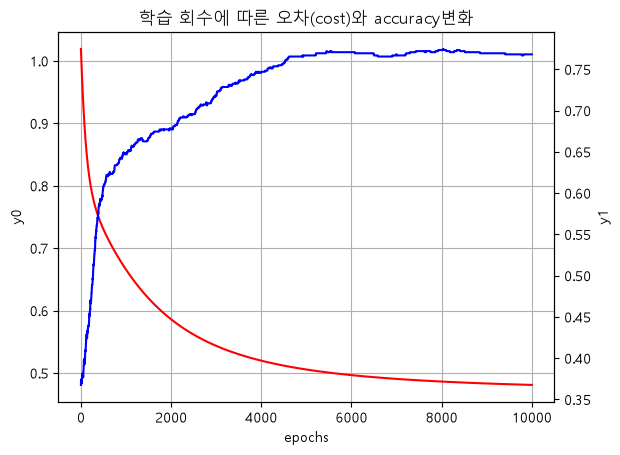

W = [[-0.6875814 ]
 [-2.4650073 ]
 [-0.39453858]
 [-0.4373169 ]
 [-0.5411764 ]
 [-2.2920463 ]
 [-0.7794658 ]
 [-0.08551849]]
b = 0.19328198
Accuracy = 0.7681159420289855


In [ ]:
############################################################################
### ppt 712 당뇨데이터를 활용한 당뇨 예측 (다중로지스틱회귀) tf 2.x ############
############################################################################
import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt

# 당뇨병 데이터 읽어오기
xy = np.loadtxt('Data/data-03-diabetes.csv', delimiter=',', dtype=np.float32)
# xy = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/data-03-diabetes.csv', delimiter=',', dtype=np.float32)
x_data = xy[:, 0:-1]     ## 0~7열 까지 총 8개 x값
y_data = xy[:, [-1]]     ## 마지막 열(9열)

W = tf.Variable(tf.random.normal([8, 1]), name='weight')
b = tf.Variable(tf.random.normal([1]), name='bias')

# Hypothesis
def hypothesis(W, b) :
    return tf.sigmoid(tf.matmul(x_data, W) + b)

############################################################################
### ppt 712 당뇨데이터를 활용한 당뇨 예측 (다중로지스틱회귀) tf 2.x ############
############################################################################

def cost(W, b):
    return - tf.reduce_mean(y_data * tf.math.log(hypothesis(W, b)) + 
                           (1 - y_data) * tf.math.log(1 - hypothesis(W, b)))

def graph():
    #import matplotlib as mpl
    plt.rc('font', family='Malgun Gothic') # 한글 설정
    plt.rc('axes', unicode_minus=False)    # 음수부호 설정
    fig, ax0 = plt.subplots()
    ax1 = ax0.twinx()   # x축을 공유하는 두개의 y축
    ax0.set_title("학습 회수에 따른 오차(cost)와 accuracy변화")
    ax0.plot(cost_arr, 'r-', label="y0")
    ax0.set_ylabel("y0")
    ax0.grid(True)
    ax1.plot(accuracy_arr, 'b', label="y1")
    ax1.set_ylabel("y1")
    ax1.grid(False)
    ax0.set_xlabel("epochs")
    plt.show()

opt = tf.keras.optimizers.SGD(learning_rate=0.01)

epoch_arr = []
cost_arr = []
accuracy_arr = []

############################################################################
### ppt 712 당뇨데이터를 활용한 당뇨 예측 (다중로지스틱회귀) tf 2.x ############
############################################################################

for step in range(10001): # steps
    with tf.GradientTape() as tape:
        cost_value = cost(W, b)
    gradients = tape.gradient(cost_value, [W, b])
    opt.apply_gradients(zip(gradients, [W, b]))
    
    predicted = tf.cast(hypothesis(W, b) > 0.5, dtype=tf.float64) ## 학습중인 W, b로 예측한 값(텐서)
    epoch_arr.append(step)                    # 학습수 누적 array
    cost_arr.append(cost_value.numpy())       # cost 누적 array
    accuracy = np.mean(y_data == predicted)   # y_data와 계산된 predicted 요소가 일치하는 확률
    accuracy_arr.append(accuracy)             # accuracy 누적 array
    
    if step % 500 == 0: 
        print("epochs=%d, cost=%.8f, W1=%.8f, W2=%.8f,... b=%.8f, accuracy=%.8f" % 
              (step, cost_value, W.numpy()[0,0], W.numpy()[1, 0], b.numpy()[0], accuracy)) 


graph()   # cost와 accuracy 그래프 그리기

print("========================================================")
print("W =", W.numpy())
print("b =", b.numpy()[0])
# print("y_data =", y_data)
# print("sigmoid =", hypothesis(W, b).numpy())

predicted = tf.cast(hypothesis(W, b) > 0.5, dtype=tf.float64)
accuracy = np.mean(y_data == predicted) 
# accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted, y_data), dtype=tf.float64)).numpy()

# print("predicted =", predicted.numpy())
print("Accuracy =", accuracy)